In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [7]:
# Random generator
rng = np.random.default_rng(42)

n = 50  # number of samples per dataset

# Categories of correlation coefficients
correlation_values = [-1, -0.8, -0.5, 0, 0.5, 0.8, 1]
category_names = [
    "Perfect negative",
    "Strong negative",
    "Moderate negative",
    "Uncorrelated",
    "Moderate positive",
    "Strong positive",
    "Perfect positive"]

# Store data for plotting
X_list = []
Y_list = []

# Base X values
X_base = np.linspace(0, 10, n)

# Generate Y for each correlation category
for r in correlation_values:
    if abs(r) == 1:
        # Perfect correlation
        Y = r*X_base
    else:
        # Linear correlation with noise
        # Calculate noise standard deviation to achieve approximate correlation
        # Correlation formula: r = cov(X,Y)/(std(X)*std(Y))
        noise_std = np.sqrt(1 - r**2)
        Y = r*X_base + rng.normal(0, noise_std, n)
    X_list.append(X_base)
    Y_list.append(Y)


In [8]:
# Compute actual correlations to show
for i, (X, Y) in enumerate(zip(X_list, Y_list)):
    r = np.corrcoef(X, Y)[0,1]
    print(f"{category_names[i]} (target {correlation_values[i]}): actual r = {r:.2f}")


Perfect negative (target -1): actual r = -1.00
Strong negative (target -0.8): actual r = -0.98
Moderate negative (target -0.5): actual r = -0.93
Uncorrelated (target 0): actual r = 0.04
Moderate positive (target 0.5): actual r = 0.89
Strong positive (target 0.8): actual r = 0.96
Perfect positive (target 1): actual r = 1.00


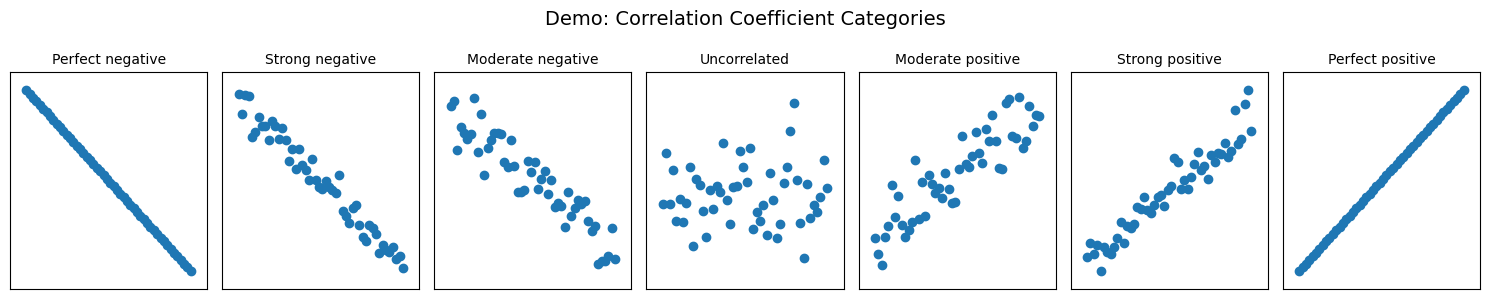

In [9]:
plt.figure(figsize=(15,3))

for i, (X, Y) in enumerate(zip(X_list, Y_list)):
    plt.subplot(1,7,i+1)
    plt.scatter(X, Y, color='C0')
    plt.title(category_names[i], fontsize=10)
    plt.xticks([])
    plt.yticks([])
    plt.ylim(min(Y)-1, max(Y)+1)
    plt.xlim(min(X)-1, max(X)+1)
    
plt.suptitle("Demo: Correlation Coefficient Categories", fontsize=14)
plt.tight_layout()
plt.show()


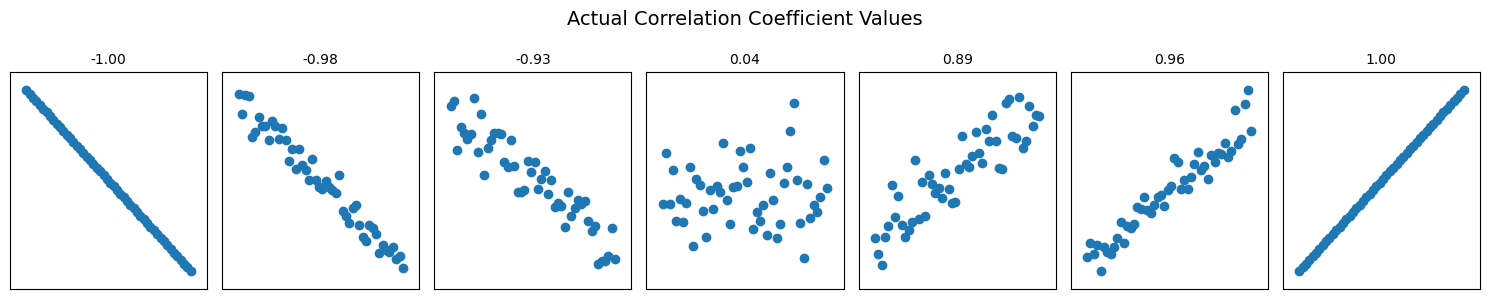

In [10]:
plt.figure(figsize=(15,3))

for i, (X, Y) in enumerate(zip(X_list, Y_list)):
    plt.subplot(1,7,i+1)
    plt.scatter(X, Y, color='C0')
    r = np.corrcoef(X, Y)[0,1]
    plt.title(f"{r:.2f}", fontsize=10)
    plt.xticks([])
    plt.yticks([])
    plt.ylim(min(Y)-1, max(Y)+1)
    plt.xlim(min(X)-1, max(X)+1)
    
plt.suptitle("Actual Correlation Coefficient Values", fontsize=14)
plt.tight_layout()
plt.show()
